In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# 2. Change the current working directory to the sandbox folder
import os
# Update this path if you placed the folder somewhere else in your Drive
repo_path = '/content/drive/MyDrive/dl-gen-lyrics'
sandbox_path = os.path.join(repo_path, 'sandbox')
os.chdir(sandbox_path)
print("Current Working Directory:", os.getcwd())

# 3. Add the 'src' directory to the Python path so local imports work
import sys
src_path = os.path.abspath(os.path.join(repo_path, 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

Current Working Directory: /content/drive/MyDrive/dl-gen-lyrics/sandbox


In [3]:
# 4. Install requirements (optional but recommended)
# !pip install -r ../requirements.txt
!pip install -q contractions>=0.1.73
!pip install -q bert-score>=0.3.13
!pip install mauve-text>=0.3.0
!pip install json5

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'/content/drive/MyDrive/dl-gen-lyrics/sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_tetra import *
from aspect_cobalt import Cobalt

In [4]:
try:
    batch_count = 20*1024
    genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'rap', 'rb', 'misc', 'pop', 'rock', 'country'}
20480


In [5]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50
except:
    traceback.print_exc()

In [6]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [7]:
try:
    cobalt = Cobalt(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp/lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached
Loaded Cache for Cobalt._prepare_training_data.cached


In [8]:
try:
    print(cobalt.training_data.head())
except:
    traceback.print_exc()

0    [17, 2660, 68, 15, 2855, 26, 902, 16, 17, 1796...
1    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
2    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
3    [17, 2660, 68, 15, 7403, 297, 5743, 16, 17, 17...
4    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
Name: tag, dtype: object


In [9]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

BiGRULyricsModel(vocab=16000, embed=512, hidden=512, layers=2, params=16,611,456)


In [10]:
print("Language Model Parameters:", cobalt.get_language_model_parameter_count())
print("Embedder Parameters:", cobalt.get_embedder_parameter_count())

Language Model Parameters: 8419456
Embedder Parameters: 8192000


In [13]:
# Print the batch size used by the DataLoader
print("Batch Size:", cobalt.language_model.trainer.train_dataloader.batch_size)

# Print the sequence length used by the LyricsDataset
print("Sequence Length:", cobalt.language_model.trainer.train_dataloader.dataset.seq_len)

Batch Size: 20
Sequence Length: 1024


In [11]:
try:
    if train_language_model:

        cobalt.language_model.trainer.device = 'cuda'

        for pg in cobalt.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0001
            print(pg['lr'])

        cobalt.language_model.embedding.weight.requires_grad = True
        print(cobalt.language_model.embedding.weight.requires_grad)

except:
    traceback.print_exc()

0.0003
True


In [ ]:
try:
    if train_language_model:
        cobalt.language_model.trainer.train()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 1.31    TTS: 1.06    ETA: 5404.31
Epoch:  0/ 1    Train Loss: 1.31    TTS: 2.15    ETA: 5491.60
Epoch:  0/ 1    Train Loss: 1.31    TTS: 3.13    ETA: 5317.11
Epoch:  0/ 1    Train Loss: 1.31    TTS: 4.11    ETA: 5239.56
Epoch:  0/ 1    Train Loss: 1.31    TTS: 5.08    ETA: 5181.80
Epoch:  0/ 1    Train Loss: 1.31    TTS: 6.08    ETA: 5164.85
Epoch:  0/ 1    Train Loss: 1.31    TTS: 7.07    ETA: 5148.42
Epoch:  0/ 1    Train Loss: 1.31    TTS: 8.08    ETA: 5146.36
Epoch:  0/ 1    Train Loss: 1.31    TTS: 9.09    ETA: 5148.66
Epoch:  0/ 1    Train Loss: 1.31    TTS: 10.11    ETA: 5148.78
Epoch:  0/ 1    Train Loss: 1.31    TTS: 11.12    ETA: 5150.26
Epoch:  0/ 1    Train Loss: 1.31    TTS: 12.14    ETA: 5151.30
Epoch:  0/ 1    Train Loss: 1.31    TTS: 13.15    ETA: 5152.47
Epoch:  0/ 1    Train Loss: 1.31    TTS: 14.18    ETA: 5158.05
Epoch:  0/ 1    Train Loss: 1.31    TTS: 15.22    ETA: 5164.09
Epoch:  0/ 1    Train Loss: 1.31    TTS: 16.26    ETA: 5172.19
E

In [27]:
try:
    if train_language_model:
        timers = cobalt.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.005372912104250148
batch 0.992891845120889


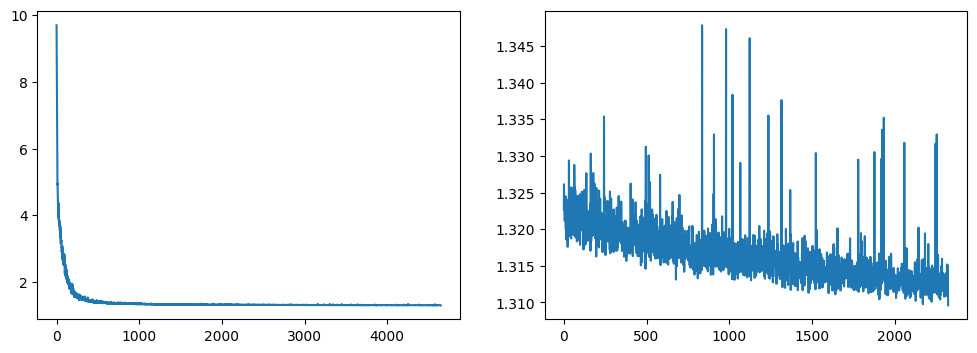

In [28]:
try:
    if train_language_model:
        loss = cobalt.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [29]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Cobalt._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: cobalt.language_model, group='Cobalt._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [30]:
try:
    print(cobalt.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

<genre_rock> <theme_black> <theme_enter> <theme_spell> <theme_priests> <theme_dragon> <SONG_START>
is get " but i ) <NE>_LINE> <CHORUS>
, this'm me baby <NEW_LINE>' i know you will
<SONG_END>


In [19]:
evaluator = SolutionEvaluator(cobalt)

In [20]:
evaluator.compute_perplexity(n_sample=10, batch_size=10)

ValueError: Expected input batch_size (15240) to match target batch_size (14970).

In [ ]:
evaluator.compute_self_bleu(n_sample=10, batch_size=10)

KeyboardInterrupt: 

In [ ]:
evaluator.compute_mauve(n_sample=10, batch_size=10)

KeyboardInterrupt: 

In [ ]:
evaluator.compute_bertscore(n_sample=10, batch_size=10)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Featurizing p:   0%|          | 0/10 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/10 [00:00<?, ?it/s]

ValueError: Expected input batch_size (17340) to match target batch_size (16940).